# **IBL brain-wide map dataset**

## **1. Installation and setup**

The code blocks in this section install and import required packages. We also define a set of utility functions that will be used to download and load data throughout the rest of the tutorial. **Make sure these cells are run before continuing onto the next sections.**

### **Install dependencies**

In [1]:
! pip install ONE-api --quiet
! pip install ibllib --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 17.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.0/140.0 kB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.5/11.5 MB 35.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.4/15.4 MB 25.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 90.1/90.1 kB 1.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.4/48.4 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 41.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.9/57.9 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 442.6/442.6 kB 23.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 102.6/102.6 kB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.0/48.0 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 226.1/226.1

### **Setup ONE**

In [2]:
# When running in jupyter set number of threads to 1
import os
os.environ.setdefault('ONE_HTTP_DL_THREADS', '1')

from one.api import ONE
ONE.setup(base_url='https://openalyx.internationalbrainlab.org', silent=True)
one = ONE(password='international')

Connected to https://openalyx.internationalbrainlab.org as user "intbrainlab"


### **Define imports**

In [4]:
!pip install quantities
!pip install neo
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import pandas as pd
from scipy import sparse
import numpy as np
from one.remote.aws import s3_download_file
import zipfile
import tqdm
import scipy.stats as stats
from iblutil.util import Bunch
from scipy.ndimage import gaussian_filter1d
import quantities as pq
import neo

from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

# This is to view dataframe interactively in Google colab
if 'google.colab' in sys.modules:
    from google.colab import data_table
    data_table.enable_dataframe_formatter()

# This is to style figures
if sys.version_info >= (3, 10):
    from ibl_style.style import figure_style
    figure_style()

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.0/104.0 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 712.5/712.5 kB 8.2 MB/s eta 0:00:00


### **Define loading utility functions**

In [5]:
def download_data(event):
  assert event in ['firstMove', 'stimOn', 'feedback'], 'event must be one of "firstMove", "stimOn" or "feedback'

  # Dataset name
  fname = f'data_{event}.zip'
  # Remote location of data
  s3_data_path = f'sample_data/Neuromatch/{fname}'
  # Local location to download data to
  save_path = one.cache_dir.joinpath('Neuromatch', fname)
  save_path.parent.mkdir(exist_ok=True, parents=True)

  # Download file
  file = s3_download_file(s3_data_path, save_path)
  # Unzip content
  with zipfile.ZipFile(file, 'r') as zip_ref:
    zip_ref.extractall(save_path.parent)


def get_data_path(event):

  return one.cache_dir.joinpath('Neuromatch', f'data_{event}')


def load_metadata(event):
  metadata = Bunch()
  data_path = get_data_path(event)
  metadata['clusters'] = pd.read_parquet(data_path.joinpath('clusters.pqt'))
  metadata['trials'] = pd.read_parquet(data_path.joinpath('trials.pqt'))
  metadata['sessions'] = pd.read_parquet(data_path.joinpath('sessions.pqt'))
  metadata['times'] = np.load(data_path.joinpath('t.npy'))
  metadata['nbins'] = metadata['times'].size
  metadata['dt'] = np.round(np.median(np.diff(metadata['times'])), 2)
  metadata['data_path'] = data_path

  return metadata


def load_times(data_path):
  return np.load(data_path.joinpath('t.npy'))


def load_psth(data_path, pid, nbins=150):
    psth = sparse.load_npz(data_path.joinpath(f'{pid}.npz')).toarray()
    psth = psth.reshape(psth.shape[0], -1, nbins)
    return psth

### **Define processing utility functions** <a name="Utility-functions"></a>

In [6]:
def split_trials_by_variable(trials, split='contrast'):
  trials = trials.set_index('psth_index')
  if split == 'contrast':
    trials['contrast'] = np.nansum([trials['contrastLeft'], trials['contrastRight']], axis=0) * 100
    grp = trials.groupby('contrast')
  elif split == 'signed contrast':
    trials['signedContrast'] = np.nansum([-1 * trials['contrastLeft'], trials['contrastRight']], axis=0) * 100
    grp = trials.groupby('signedContrast')
  elif split == 'stimulus':
    trials['stimulus'] = 'right'
    trials.loc[trials['contrastRight'].isna(), 'stimulus'] = 'left'
    grp = trials.groupby('stimulus')
  elif split == 'choice':
    grp = trials.groupby('choice')
  elif split == 'block':
    grp = trials.groupby('probabilityLeft')
  else:
    raise NotImplementedError('split must be one of "contrast", "signed contrast", "stimulus", "choice" or "block"')

  return grp.groups


def get_avg_psth_for_insertion(pid, meta, reg=None, uuids=None, split=None):

  df = meta.clusters[meta.clusters['pid'] == pid]
  df = df[['acronym', 'pid', 'uuids', 'cluster_id', 'psth_index']]
  sp = load_psth(meta.data_path, pid, nbins=meta.nbins)

  if reg is not None:
    in_reg = df['acronym'] == reg
    sp = sp[:, in_reg.values, :]
    df = df[in_reg].reset_index(drop=True)

  if uuids is not None:
    in_uuid = df['uuids'].isin(uuids)
    sp = sp[:, in_uuid.values, :]
    df = df[in_uuid].reset_index(drop=True)

  if split is None:
    psth = sp.mean(axis=0) / meta['dt']
  else:
    psth = dict()
    eid = meta.sessions[meta.sessions['pid'] == pid].iloc[0]['eid']
    trials = meta.trials[meta.trials['eid'] == eid].reset_index(drop=True)
    grps = split_trials_by_variable(trials, split=split)

    for key, vals in grps.items():
      psth[key] = sp[vals, :, :].mean(axis=0)

  return psth, df

def get_avg_psth_for_region(reg, meta, split=None):
  clusters = meta.clusters[meta.clusters['acronym'] == reg]
  pids = clusters['pid'].unique()
  all_df = []
  all_psth = []
  for pid in pids:
    psth, df = get_avg_psth_for_insertion(pid, meta, reg=reg, split=split)
    all_df.append(df)
    all_psth.append(psth)

  all_df = pd.concat(all_df).reset_index(drop=True)
  if split is None:
    all_psth = np.concatenate(all_psth)
  else:
    all_psth = {key: np.concatenate([d[key] for d in all_psth if key in d.keys()])
    for key in all_psth[0]}


  return all_psth, all_df


def get_avg_psth_for_clusters(uuids, meta, split=None):
  clusters = meta.clusters[meta.clusters['uuids'].isin(uuids)]
  pids = clusters['pid'].unique()
  all_df = []
  all_psth = []
  for pid in pids:
    psth, df = get_avg_psth_for_insertion(pid, meta, uuids=uuids, split=split)
    all_df.append(df)
    all_psth.append(psth)

  all_df = pd.concat(all_df).reset_index(drop=True)
  if split is None:
    all_psth = np.concatenate(all_psth)
  else:
    all_psth = {key: np.concatenate([d[key] for d in all_psth if key in d.keys()])
    for key in all_psth[0]}

  return all_psth, all_df



def get_psth_for_insertion(pid, meta, reg=None, uuids=None):

  df = meta.clusters[meta.clusters['pid'] == pid]
  df = df[['acronym', 'pid', 'uuids', 'cluster_id', 'psth_index']]
  sp = load_psth(meta.data_path, pid, nbins=meta.nbins)

  if reg is not None:
    in_reg = df['acronym'] == reg
    sp = sp[:, in_reg.values, :]
    df = df[in_reg].reset_index(drop=True)

  if uuids is not None:
    in_uuid = df['uuids'].isin(uuids)
    sp = sp[:, in_uuid.values, :]
    df = df[in_uuid].reset_index(drop=True)


  eid = meta.sessions[meta.sessions['pid'] == pid].iloc[0]['eid']
  trials = meta.trials[meta.trials['eid'] == eid].reset_index(drop=True)
  psth = sp / meta['dt']

  return psth, df, trials


def get_psth_for_region(reg, meta):

  clusters = meta.clusters[meta.clusters['acronym'] == reg]
  pids = clusters['pid'].unique()
  all_clust = []
  all_psth = []
  all_trials = []
  for pid in pids:
    psth, clust, trials = get_psth_for_insertion(pid, meta, reg=reg)
    all_clust.append(clust)
    all_psth.append(psth)
    all_trials.append(trials)

  return all_psth, all_clust, all_trials


def get_psth_for_clusters(uuids, meta):

  clusters = meta.clusters[meta.clusters['uuids'].isin(uuids)]
  pids = clusters['pid'].unique()
  all_clust = []
  all_psth = []
  all_trials = []
  for pid in pids:
    psth, clust, trials = get_psth_for_insertion(pid, meta, uuids=uuids)
    all_clust.append(clust)
    all_psth.append(psth)
    all_trials.append(trials)

  return all_psth, all_clust, all_trials

In [ ]:
# Find an insertion with this region in it

clusters = meta.clusters[meta.clusters['acronym'] == 'GRN']
pids = clusters['pid'].unique()
print(pids)

In [ ]:

psth, clust, trials = get_psth_for_insertion('7332e6cf-9847-4aca-b2e3-d864989dd0fb', meta, reg='GRN')

trial_idx = 0
trial_data = psth[trial_idx, :, :]        # (n_clusters, n_bins)
trial_choice = trials.iloc[trial_idx]['choice']  # -1.0 or 1.0

print(np.shape(trial_data))
print(trial_choice)


left_idx = trials[trials['choice'] == -1.0].index[0]
right_idx = trials[trials['choice'] == 1.0].index[0]

left_trial = psth[left_idx, :, :]
right_trial = psth[right_idx, :, :]

# Single Trial PCA

In [7]:
# Download movement-aligned metadata

download_data('firstMove')
meta = load_metadata('firstMove')

(S3) /root/Downloads/ONE/openalyx.internationalbrainlab.org/Neuromatch/data_firstMove.zip: 100%|██████████| 823M/823M [00:09<00:00, 85.9MB/s]


In [8]:
# Find an insertion which contains a given region

clusters = meta.clusters[meta.clusters['acronym'] == 'MOp']
pids = clusters['pid'].unique()
print(pids)

['f475ae14-9415-453e-b800-1480ea1c868d'
 '73ff4936-8cd3-4a75-a772-f563e67d249d'
 '7b05cccc-44f6-4491-a0ea-e38d6e95513d'
 'decc8d40-cf74-4263-ae9d-a0cc68b47e86'
 'a9e83d8a-7c90-4152-abad-53a1ad94d73a'
 '2564dc27-4eda-4fc3-a151-c13475796ee1'
 '2d2cdf86-4a0c-42d8-aed3-5b187f160013'
 '79628a45-c2e3-4206-97df-4c91edaff90f'
 'e88eb9f8-fff3-469a-854d-d16adef19df0'
 'e96cbd77-5fdf-4a35-81f4-4a6361bded65'
 '7c94d733-b913-4064-83f2-37422712204c'
 '5245b505-d0e7-4942-94d1-b33a084fab03'
 '41ea689a-7e05-463b-915a-90e63b8c0572'
 '2122d807-13ab-494e-a1cc-e55cf24d3e9f'
 '26118c10-35dd-4ab1-9f0f-b9a89a1da070'
 '898f8971-31e9-4fdb-b66e-2ae6d3a33a5b'
 '0e8d3cb3-2e4c-47a0-8bb4-65d2cc3161c6'
 'd258bca2-bf18-4491-8d57-5322f705caec'
 'b375a0ee-4c5a-4a53-9cea-d753f206e5c5'
 'edc82c06-83fd-44be-a41e-52fdeea728b4'
 '0ffa052a-fe3f-46c2-999d-43bd56b7826e'
 'bef552f5-efd8-4e98-8467-d54ac7c4ef41'
 '3fd2d2b3-9415-4b6e-b392-40427fb1c388'
 '6eb8be8d-d089-43c6-b2e4-a6558ca16dcf'
 'fddceb2e-82ba-493d-baba-c5d8af65981f'


In [11]:
# Get psth/clust/trials for an insertion filtered by region (use a insertion from above)
psth, clust, trials = get_psth_for_insertion('b4131145-9675-4433-88e1-9ae016c701dd', meta, reg='MOp')

# Choose a single trial and access that PSTH and choice
trial_idx = 0

trial_data = psth[trial_idx, :, :]        # (n_clusters, n_bins)
print("Single Trial PSTH Shape:", np.shape(trial_data))

trial_choice = trials.iloc[trial_idx]['choice']  # -1.0 or 1.0
print("Single Trial Choice:", trial_choice)

Single Trial PSTH Shape: (91, 150)
Single Trial Choice: 1.0


In [13]:
# Get a single trial for a left and right choice
left_idx = trials[trials['choice'] == -1.0].index[0]
right_idx = trials[trials['choice'] == 1.0].index[0]

left_trial = psth[left_idx, :, :]
right_trial = psth[right_idx, :, :]

left_trial = gaussian_filter1d(left_trial, sigma=1)
right_trial = gaussian_filter1d(right_trial, sigma=1)

print("Shape of left trial:", np.shape(left_trial))
print("Shape of right trial:", np.shape(right_trial))

Shape of left trial: (91, 150)
Shape of right trial: (91, 150)


In [14]:
# Get only data prior to movement onset
pre_mov_time_window = meta.times < 0
combined_l_r_psth_single_trial = np.concatenate([left_trial[:, pre_mov_time_window], right_trial[:, pre_mov_time_window]], axis=1)

print("Shape of left/right combined psth for single trial:", np.shape(combined_l_r_psth_single_trial))

Shape of left/right combined psth for single trial: (91, 100)


In [15]:
# Perform PCA, retrieving 2 components
pca = PCA(n_components=6)
trajs = pca.fit_transform(combined_l_r_psth_single_trial.T).T

# Extract trajectories for left and right choice
pca_traj_right = trajs[:, :pre_mov_time_window.sum()]
pca_traj_left = trajs[:, pre_mov_time_window.sum():]

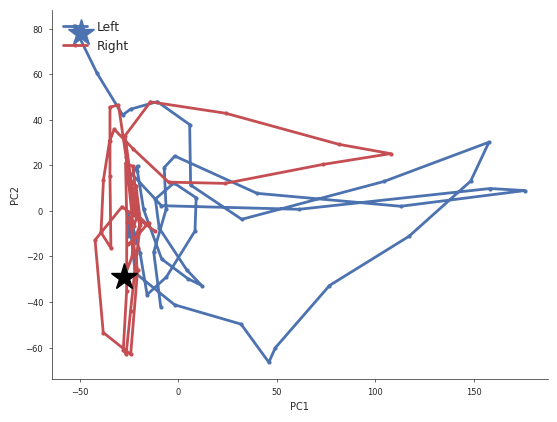

In [16]:
# Plot the trajectories
plt.plot(pca_traj_left[0, :], pca_traj_left[4, :], color='b', label='Left', marker='.', lw=2)
plt.plot(pca_traj_right[0, :], pca_traj_right[4, :], color='r', label='Right', marker='.', lw=2)
# Mark the start
plt.plot(pca_traj_left[0, 0], pca_traj_left[4, 0], color='b', marker='*', ms=20)
plt.plot(pca_traj_right[0, 0], pca_traj_right[4, 0], color='black', marker='*', ms=20)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend(loc=2, frameon=False)

# GPFA comparison

In [17]:
!pip install elephant

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 13.1 MB/s eta 0:00:00


In [ ]:
from elephant.gpfa import GPFA

In [ ]:
# Get all left/right trials for the insertion
left_idxs = trials[trials['choice'] == -1.0].index
right_idxs = trials[trials['choice'] == 1.0].index

left_trials = psth[left_idxs, :, :]
right_trials = psth[right_idxs, :, :]

# Trim
pre_mov_time_window = meta.times < 0

left_trials = left_trials[:, :, pre_mov_time_window]
right_trials = right_trials[:, :, pre_mov_time_window]


# print(len(left_trials))

In [ ]:
# CONVERT THE BINNED DATA INTO SPIKE TRAINS (as elephant takes in spike trains and bins them internally)

dt = meta['dt']
n_bins = left_trials.shape[2]

# Convert all left psths to spike trains
spiketrains_left = []
for trial in left_trials:
    counts = np.round(trial * dt).astype(int)
    trial_sts = []
    for neuron in range(counts.shape[0]):
        spike_times = []
        for b in range(n_bins):
            n = counts[neuron, b]
            if n > 0:
                spike_times.extend(np.linspace(b*dt, (b+1)*dt, n, endpoint=False))
        st = neo.SpikeTrain(np.sort(spike_times)*pq.s, t_start=0*pq.s, t_stop=n_bins*dt*pq.s)
        trial_sts.append(st)
    spiketrains_left.append(trial_sts)

# Convert all left psths to spike trains
spiketrains_right = []
for trial in right_trials:
    counts = np.round(trial * dt).astype(int)
    trial_sts = []
    for neuron in range(counts.shape[0]):
        spike_times = []
        for b in range(n_bins):
            n = counts[neuron, b]
            if n > 0:
                spike_times.extend(np.linspace(b*dt, (b+1)*dt, n, endpoint=False))
        st = neo.SpikeTrain(np.sort(spike_times)*pq.s, t_start=0*pq.s, t_stop=n_bins*dt*pq.s)
        trial_sts.append(st)
    spiketrains_right.append(trial_sts)

In [ ]:
# Fit GPFA on these reconstructed spike trains
gpfa = GPFA(bin_size=dt*pq.s, x_dim=10)
trajectories = gpfa.fit_transform(spiketrains_left + spiketrains_right)

n_left = len(spiketrains_left)
traj_left_trials = trajectories[:n_left]    # list of (2, n_bins) arrays
traj_right_trials = trajectories[n_left:]   # list of (2, n_bins) arrays

[2026-07-15 15:58:59,906] utils - WARNING: Correcting 1 rounding errors by shifting the affected spikes into the following bin. You can set tolerance=None to disable this behaviour.
[2026-07-15 15:58:59,908] utils - WARNING: Correcting 1 rounding errors by shifting the affected spikes into the following bin. You can set tolerance=None to disable this behaviour.
[2026-07-15 15:58:59,911] utils - WARNING: Correcting 1 rounding errors by shifting the affected spikes into the following bin. You can set tolerance=None to disable this behaviour.
[2026-07-15 15:58:59,914] utils - WARNING: Correcting 1 rounding errors by shifting the affected spikes into the following bin. You can set tolerance=None to disable this behaviour.
[2026-07-15 15:58:59,915] utils - WARNING: Correcting 1 rounding errors by shifting the affected spikes into the following bin. You can set tolerance=None to disable this behaviour.
[2026-07-15 15:58:59,917] utils - WARNING: Correcting 1 rounding errors by shifting the af

Initializing parameters using factor analysis...

Fitting GPFA model...


[2026-07-15 16:03:40,831] utils - WARNING: Correcting 1 rounding errors by shifting the affected spikes into the following bin. You can set tolerance=None to disable this behaviour.
[2026-07-15 16:03:40,834] utils - WARNING: Correcting 1 rounding errors by shifting the affected spikes into the following bin. You can set tolerance=None to disable this behaviour.
[2026-07-15 16:03:40,836] utils - WARNING: Correcting 1 rounding errors by shifting the affected spikes into the following bin. You can set tolerance=None to disable this behaviour.
[2026-07-15 16:03:40,839] utils - WARNING: Correcting 1 rounding errors by shifting the affected spikes into the following bin. You can set tolerance=None to disable this behaviour.
[2026-07-15 16:03:40,842] utils - WARNING: Correcting 1 rounding errors by shifting the affected spikes into the following bin. You can set tolerance=None to disable this behaviour.
[2026-07-15 16:03:40,844] utils - WARNING: Correcting 1 rounding errors by shifting the af

In [ ]:
# print(np.shape(traj_left_trials))

(50,)


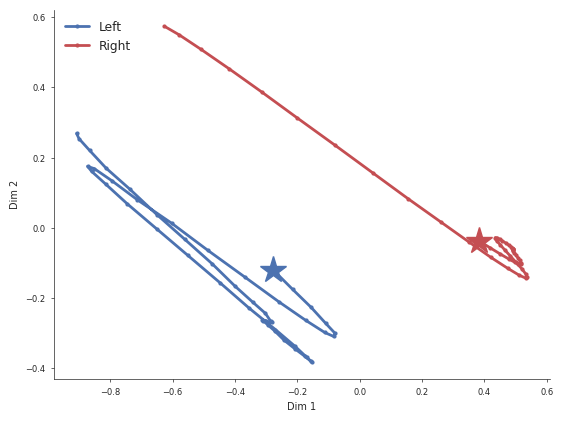

In [ ]:
traj_left = traj_left_trials[1]
traj_right = traj_right_trials[1]

plt.plot(traj_left[0, :], traj_left[1, :], color='b', label='Left',  marker='.', lw=2)
plt.plot(traj_right[0, :], traj_right[1, :], color='r', label='Right',  marker='.', lw=2)
plt.plot(traj_left[0, 0], traj_left[1, 0], color='b', marker='*', ms=20)
plt.plot(traj_right[0, 0], traj_right[1, 0], color='r', marker='*', ms=20)
plt.xlabel('Dim 1')
plt.ylabel('Dim 2')
plt.legend(loc=2, frameon=False)

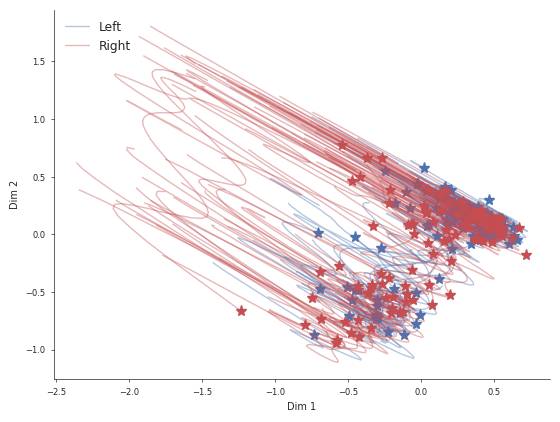

In [ ]:
for i, traj in enumerate(traj_left_trials):
    plt.plot(traj[0, :], traj[1, :], color='b', alpha=0.4, lw=1,
              label='Left' if i == 0 else None)
    plt.plot(traj[0, 0], traj[1, 0], color='b', marker='*', ms=8)

for i, traj in enumerate(traj_right_trials):
    plt.plot(traj[0, :], traj[1, :], color='r', alpha=0.4, lw=1,
              label='Right' if i == 0 else None)
    plt.plot(traj[0, 0], traj[1, 0], color='r', marker='*', ms=8)



plt.xlabel('Dim 1')
plt.ylabel('Dim 2')
plt.legend(loc=2, frameon=False)

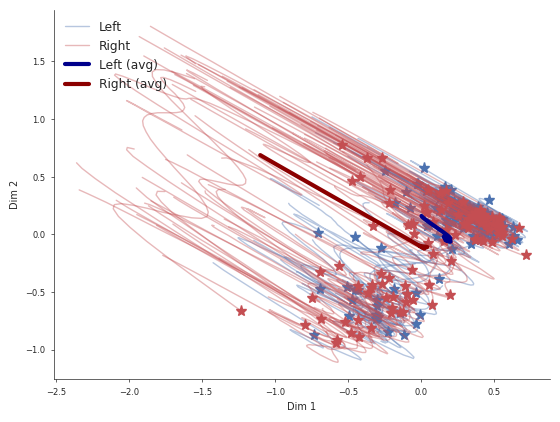

In [ ]:
import numpy as np

for i, traj in enumerate(traj_left_trials):
    plt.plot(traj[0, :], traj[1, :], color='b', alpha=0.4, lw=1,
              label='Left' if i == 0 else None)
    plt.plot(traj[0, 0], traj[1, 0], color='b', marker='*', ms=8)

for i, traj in enumerate(traj_right_trials):
    plt.plot(traj[0, :], traj[1, :], color='r', alpha=0.4, lw=1,
              label='Right' if i == 0 else None)
    plt.plot(traj[0, 0], traj[1, 0], color='r', marker='*', ms=8)

# --- Average trajectories ---
# Stack trials into a (n_trials, 2, T) array, then average over trials
avg_left = np.mean(np.stack(traj_left_trials, axis=0), axis=0)
avg_right = np.mean(np.stack(traj_right_trials, axis=0), axis=0)

plt.plot(avg_left[0, :], avg_left[1, :], color='darkblue', lw=3,
          label='Left (avg)')
plt.plot(avg_right[0, :], avg_right[1, :], color='darkred', lw=3,
          label='Right (avg)')

plt.xlabel('Dim 1')
plt.ylabel('Dim 2')
plt.legend(loc=2, frameon=False)

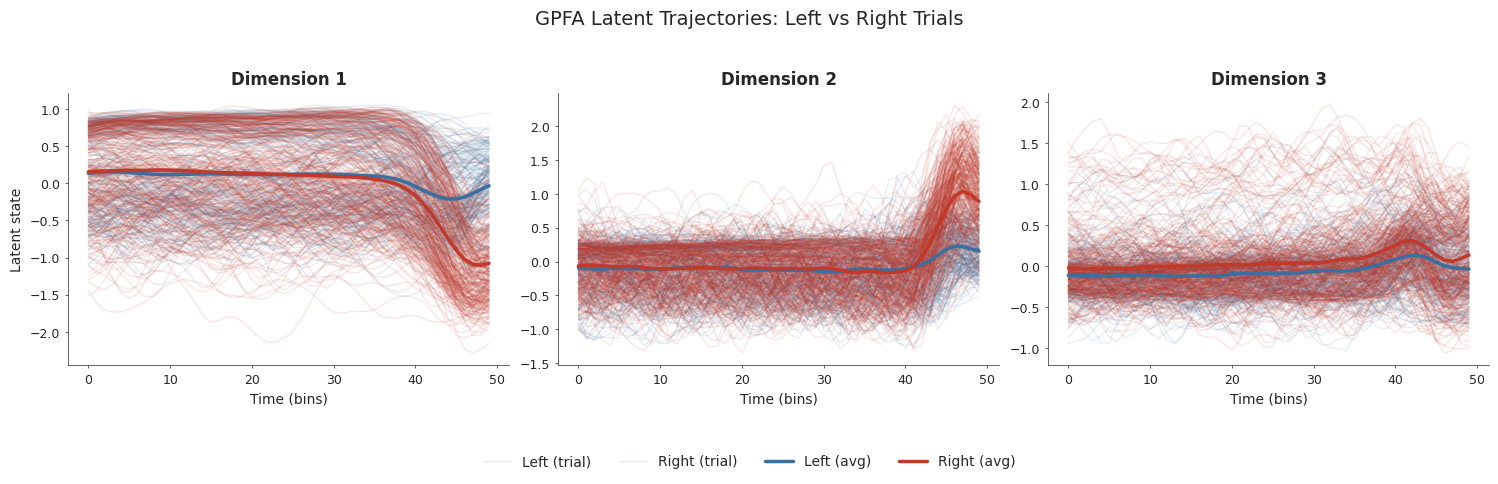

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

x_dim = trajectories[0].shape[0]  # matches GPFA(x_dim=10)

left_arr = np.stack(traj_left_trials, axis=0)    # (n_trials, x_dim, n_bins)
right_arr = np.stack(traj_right_trials, axis=0)

avg_left = left_arr.mean(axis=0)   # (x_dim, n_bins)
avg_right = right_arr.mean(axis=0)
sem_left = left_arr.std(axis=0) / np.sqrt(left_arr.shape[0])
sem_right = right_arr.std(axis=0) / np.sqrt(right_arr.shape[0])

n_dims_to_plot = 3
color_left, color_right = '#3B6FA0', '#C0392B'

fig, axes = plt.subplots(1, n_dims_to_plot, figsize=(15, 4.2), sharex=True)

for dim, ax in enumerate(axes):
    time = np.arange(avg_left.shape[1])

    # individual trials, faint (label only the first of each so legend isn't cluttered)
    for i, traj in enumerate(traj_left_trials):
        ax.plot(time, traj[dim, :], color=color_left, alpha=0.12, lw=1,
                 label='Left (trial)' if i == 0 else None)
    for i, traj in enumerate(traj_right_trials):
        ax.plot(time, traj[dim, :], color=color_right, alpha=0.12, lw=1,
                 label='Right (trial)' if i == 0 else None)

    # trial averages with SEM shading
    ax.plot(time, avg_left[dim, :], color=color_left, lw=2.5, label='Left (avg)')
    ax.fill_between(time, avg_left[dim, :] - sem_left[dim, :],
                     avg_left[dim, :] + sem_left[dim, :],
                     color=color_left, alpha=0.2, linewidth=0)

    ax.plot(time, avg_right[dim, :], color=color_right, lw=2.5, label='Right (avg)')
    ax.fill_between(time, avg_right[dim, :] - sem_right[dim, :],
                     avg_right[dim, :] + sem_right[dim, :],
                     color=color_right, alpha=0.2, linewidth=0)

    ax.set_title(f'Dimension {dim + 1}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Time (bins)', fontsize=10)
    if dim == 0:
        ax.set_ylabel('Latent state', fontsize=10)

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(labelsize=9)

# single shared legend below the figure
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=4, frameon=False,
           bbox_to_anchor=(0.5, 0.02), fontsize=10)

fig.suptitle('GPFA Latent Trajectories: Left vs Right Trials', y=1.05, fontsize=14)
plt.tight_layout(rect=[0, 0.08, 1, 1])  # leave room at bottom for legend
plt.show()

# GPFA, multiple regions